## 📘 Notebook Summary

This notebook processes GraphCast GFS forecast data to:

- Inspect included variables and datasets
- Define Bhutan's spatial extent
- Analyze variable availability across forecast hours
- Extract and visualize time series (e.g., total precipitation)

The workflow focuses on total precipitation but is adaptable to other weather variables.


In [1]:
import cfgrib
import xarray as xr
import os
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
base_dir = "../../graphcastgfs_downloads"

### Inspect GRIB2 file to identify included datasets and variables

We select one GRIB2 file (forecast hour 6) to inspect its contents.  
This helps us understand how many datasets it includes, what variables are available,  
and the structure (dimensions) of each dataset.

**Summary of contents:**
- **Dataset 0**: `u10`, `v10` (10-meter wind components)  
- **Dataset 1**: `t2m` (2-meter temperature)  
- **Dataset 2**: Multiple pressure-level variables: `t`, `u`, `v`, `q`, `w`, `gh`  
- **Dataset 3**: `prmsl` (mean sea level pressure)  
- **Dataset 4**: `tp` (total precipitation)  
All variables (except Dataset 2) share the same 2D spatial grid: `latitude` (721) × `longitude` (1440).  
Dataset 2 includes pressure levels (`isobaricInhPa`: 13 levels) in addition to spatial dimensions.


In [3]:
# Pick one file to inspect
file_path = os.path.join(base_dir, "graphcastgfs.t00z.pgrb2.0p25.f006")

# Load all message groups from this GRIB2 file
datasets = cfgrib.open_datasets(file_path, filter_by_keys={'centre': 'kwbc'})

# Inspect what's inside
print(f"Found {len(datasets)} datasets")
for i, ds in enumerate(datasets):
    print(f"\n--- Dataset {i} ---")
    print("Variables:", list(ds.data_vars))
    print("Dimensions:", ds.dims)

Found 5 datasets

--- Dataset 0 ---
Variables: ['u10', 'v10']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

--- Dataset 1 ---
Variables: ['t2m']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

--- Dataset 2 ---
Variables: ['t', 'u', 'v', 'q', 'w', 'gh']
Dimensions: Frozen({'isobaricInhPa': 13, 'latitude': 721, 'longitude': 1440})

--- Dataset 3 ---
Variables: ['prmsl']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

--- Dataset 4 ---
Variables: ['tp']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})


### Define Bhutan region bounding box (aligned with ERA5 cropping convention)

The bounding box for Bhutan is set to match the spatial extent used when cropping ERA5 data.  
This ensures consistency across different datasets used in our analysis and modeling.


In [4]:
# Define Bhutan region bounding box
lat_bounds = slice(28.5, 26.5)   # latitude is descending
lon_bounds = slice(88.5, 92.0)

This section selects and processes four key weather datasets:
- 10m wind (u10/v10)
- 2m temperature (t2m)
- Mean sea level pressure (MSLP)
- Total precipitation (tp)

For each selected dataset:
- The variable is spatially cropped to the Bhutan region.
- Its variable name and shape are printed.
- A quick visualization is generated for manual inspection.

Note: This is based on forecast hour = 6 (f006).



10m wind (u10/v10) – Variable: u10
Shape: (9, 15)


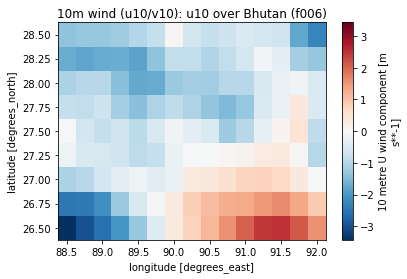


10m wind (u10/v10) – Variable: v10
Shape: (9, 15)


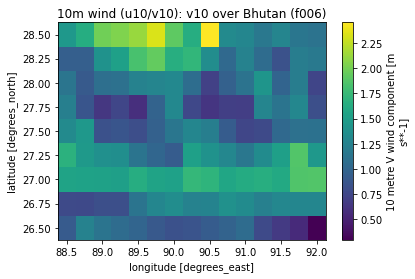


2m temp (t2m) – Variable: t2m
Shape: (9, 15)


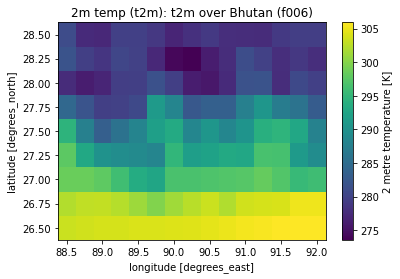


MSLP (prmsl) – Variable: prmsl
Shape: (9, 15)


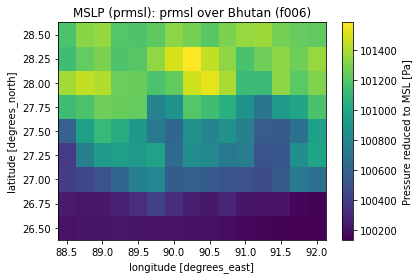


Total precip (tp) – Variable: tp
Shape: (9, 15)


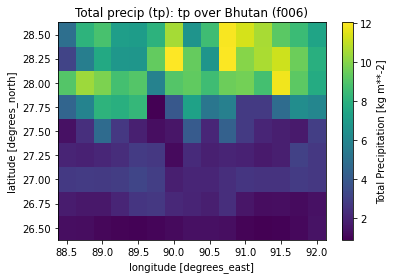

In [5]:
# We'll process datasets 0, 1, 3, 4
selected_indices = [0, 1, 3, 4]
selected_names = ['10m wind (u10/v10)', '2m temp (t2m)', 'MSLP (prmsl)', 'Total precip (tp)']

for i, name in zip(selected_indices, selected_names):
    ds = datasets[i]

    # Crop to Bhutan region
    ds_bhutan = ds.sel(latitude=lat_bounds, longitude=lon_bounds)

    # Print variable names and shape
    for var in ds_bhutan.data_vars:
        print(f"\n{name} – Variable: {var}")
        print("Shape:", ds_bhutan[var].shape)

        # Plot the variable
        ds_bhutan[var].plot()
        plt.title(f"{name}: {var} over Bhutan (f006)")
        plt.show()

### We now extend the analysis to cover multiple forecast hours.

First, we verify whether each forecast hour includes the same weather variables.  
Observation: the forecast at hour `00` does **not** contain `tp` (total precipitation), while the others (e.g., hour 06, 12, etc.) do include all target variables.  
→ We will skip hour 00 when analyzing `tp`, but it can still be used for other variables.


In [6]:
# Forecast hours you want to load (adjust as needed)
forecast_hours = [f"f{str(h).zfill(3)}" for h in range(0, 75, 6)]  # f000, f006, ..., f072

# Loop through forecast files
for hour in forecast_hours:
    file_name = f"graphcastgfs.t00z.pgrb2.0p25.{hour}"
    file_path = os.path.join(base_dir, file_name)

    print(f"\n==== Loading {file_name} ====")
    try:
        datasets = cfgrib.open_datasets(file_path, filter_by_keys={'centre': 'kwbc'})
        print(f"Found {len(datasets)} datasets")

        for i, ds in enumerate(datasets):
            print(f"\n—— Dataset {i} ——")
            print("Variables:", list(ds.data_vars))
            print("Dimensions:", ds.dims)

    except Exception as e:
        print(f"Failed to load {file_name}: {e}")



==== Loading graphcastgfs.t00z.pgrb2.0p25.f000 ====
Found 4 datasets

—— Dataset 0 ——
Variables: ['u10', 'v10']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

—— Dataset 1 ——
Variables: ['t2m']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

—— Dataset 2 ——
Variables: ['t', 'u', 'v', 'q', 'w', 'gh']
Dimensions: Frozen({'isobaricInhPa': 13, 'latitude': 721, 'longitude': 1440})

—— Dataset 3 ——
Variables: ['prmsl']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

==== Loading graphcastgfs.t00z.pgrb2.0p25.f006 ====
Found 5 datasets

—— Dataset 0 ——
Variables: ['u10', 'v10']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

—— Dataset 1 ——
Variables: ['t2m']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

—— Dataset 2 ——
Variables: ['t', 'u', 'v', 'q', 'w', 'gh']
Dimensions: Frozen({'isobaricInhPa': 13, 'latitude': 721, 'longitude': 1440})

—— Dataset 3 ——
Variables: ['prmsl']
Dimensions: Frozen({'latitude': 721, 'longitude': 1440})

—— Data

### Plot time series across forecast hours

We use `tp` (total precipitation) as an example here. Note that forecast hour = 0 is skipped
because the `tp` variable is not included in that file.  
This workflow can be easily extended to other weather variables (e.g., `t2m`, `u10`, `v10`, `prmsl`)
with small adjustments to the code.


In [7]:
selected_var_key = 'tp'  # Only collect this variable's values

# --- Collect tp values across forecast hours ---
tp_values_list = []

for hour in forecast_hours:
    if hour == 'f000':
        continue  # Skip hour 0
    file_name = f"graphcastgfs.t00z.pgrb2.0p25.{hour}"
    file_path = os.path.join(base_dir, file_name)
    
    try:
        datasets = cfgrib.open_datasets(file_path, filter_by_keys={'centre': 'kwbc'})
    except Exception as e:
        print(f"Skipping {file_name}: {e}")
        continue

    ds = datasets[selected_indices[-1]]  # 'tp' is the last in selected_indices
    ds_bhutan = ds.sel(latitude=lat_bounds, longitude=lon_bounds)
    tp_array = ds_bhutan[selected_var_key].values
    tp_values_list.append(tp_array)
    print(f"Loaded {file_name} | shape: {tp_array.shape}")
    
# --- Convert to np array (time, lat, lon) ---
tp_values_all = np.stack(tp_values_list, axis=0)  # shape: (time, lat, lon)
print("Final stacked shape:", tp_values_all.shape)

Loaded graphcastgfs.t00z.pgrb2.0p25.f006 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f012 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f018 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f024 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f030 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f036 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f042 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f048 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f054 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f060 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f066 | shape: (9, 15)
Loaded graphcastgfs.t00z.pgrb2.0p25.f072 | shape: (9, 15)
Final stacked shape: (12, 9, 15)


In [8]:
# Function to plot tp time series at given indices
def plot_tp_series(lat_idx=0, lon_idx=0):
    tp_series = tp_values_all[:, lat_idx, lon_idx]
    forecast_hours = list(range(6, 6 + 6 * len(tp_series), 6))

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_hours, tp_series, marker='o')
    plt.title(f"Total Precipitation (tp) at grid point [lat_idx={lat_idx}, lon_idx={lon_idx}]")
    plt.xlabel("Forecast Hour")
    plt.ylabel("Precipitation (mm)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create sliders with correct bounds
_, nlat, nlon = tp_values_all.shape
interact(plot_tp_series,
         lat_idx=widgets.IntSlider(min=0, max=nlat-1, step=1, value=nlat//2),
         lon_idx=widgets.IntSlider(min=0, max=nlon-1, step=1, value=nlon//2))


interactive(children=(IntSlider(value=4, description='lat_idx', max=8), IntSlider(value=7, description='lon_id…

<function __main__.plot_tp_series(lat_idx=0, lon_idx=0)>